# E-commerce EDA — Unified Data Platform

Exploratory analysis of the star-schema warehouse produced by `run_all.py`
(`database/warehouse.db`). Read this after running `python3 run_all.py`
from the repo root at least once — this notebook reads that file directly,
doesn't regenerate it.

**Data note:** this is synthetic demo data — the point of this notebook
is to show the analysis workflow and how it fed back into the DQ rules,
not to report on a real business.

Sections:
1. Data overview (shape, types, missingness)
2. Customers — age & signup distributions
3. Products — price distributions by category
4. Sales over time
5. Anomaly days (from `ml/anomaly_detection.py`'s output)
6. Reviews & sentiment (`fact_reviews`, lexicon-based)
7. DQ scores for the tables above, and notes on how EDA findings shaped the DQ rules


In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DB_PATH = os.path.join(REPO_ROOT, "database", "warehouse.db")
DQ_HISTORY_PATH = os.path.join(REPO_ROOT, "dq", "quality_history.db")

assert os.path.exists(DB_PATH), f"warehouse.db not found at {DB_PATH} — run `python3 run_all.py` from the repo root first."

conn = sqlite3.connect(DB_PATH)
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
tables

,name
0,dim_customer
1,dim_product
2,dim_date
3,fact_sales
4,sqlite_sequence
5,fact_reviews


## 1. Data overview

In [2]:
dim_customer = pd.read_sql("SELECT * FROM dim_customer", conn)
dim_product  = pd.read_sql("SELECT * FROM dim_product", conn)
fact_sales   = pd.read_sql("SELECT * FROM fact_sales", conn, parse_dates=["date_id"] if "date_id" in pd.read_sql("SELECT * FROM fact_sales LIMIT 0", conn).columns else None)

for name, df in [("dim_customer", dim_customer), ("dim_product", dim_product), ("fact_sales", fact_sales)]:
    print(f"--- {name}: {df.shape[0]:,} rows x {df.shape[1]} cols ---")
    print(df.dtypes.to_string())
    print()

--- dim_customer: 2,000 rows x 6 cols ---
customer_id     int64
name           object
city           object
signup_date    object
age             int64
age_group      object

--- dim_product: 300 rows x 6 cols ---
product_id        int64
product_name     object
category         object
unit_price      float64
cost_price      float64
margin_pct      float64

--- fact_sales: 86,052 rows x 10 cols ---
sale_id                  int64
order_id                 int64
item_id                  int64
customer_id              int64
product_id               int64
date_id         datetime64[ns]
quantity                 int64
unit_price             float64
total_amount           float64
status                  object



In [3]:
missing = pd.DataFrame({
    "dim_customer": dim_customer.isna().mean(),
    "dim_product": pd.Series({c: dim_product[c].isna().mean() for c in dim_product.columns}),
}).fillna(0).round(4)
print("Fraction missing per column (0 = no missing values seen after ETL/DQ-gate cleanup):")
missing

Fraction missing per column (0 = no missing values seen after ETL/DQ-gate cleanup):


,dim_customer,dim_product
age,0.0,0.0
age_group,0.0,0.0
category,0.0,0.0
city,0.0,0.0
cost_price,0.0,0.0
customer_id,0.0,0.0
margin_pct,0.0,0.0
name,0.0,0.0
product_id,0.0,0.0
product_name,0.0,0.0


**Note:** most columns show 0% missing here — that's expected, not
a given. The raw extract had real nulls and duplicates (see
`dq/customers_orders.csv`, a separate sample file used to exercise the DQ
system standalone); the ETL's transform + validate + DQ-gate steps are
what get the warehouse tables to this state, and the DQ gate would have
blocked the load if a table's score had fallen below threshold. That's
the link between this notebook and `dq/quality_gate.py` — see section 7.

## 2. Customers — age & signup distributions

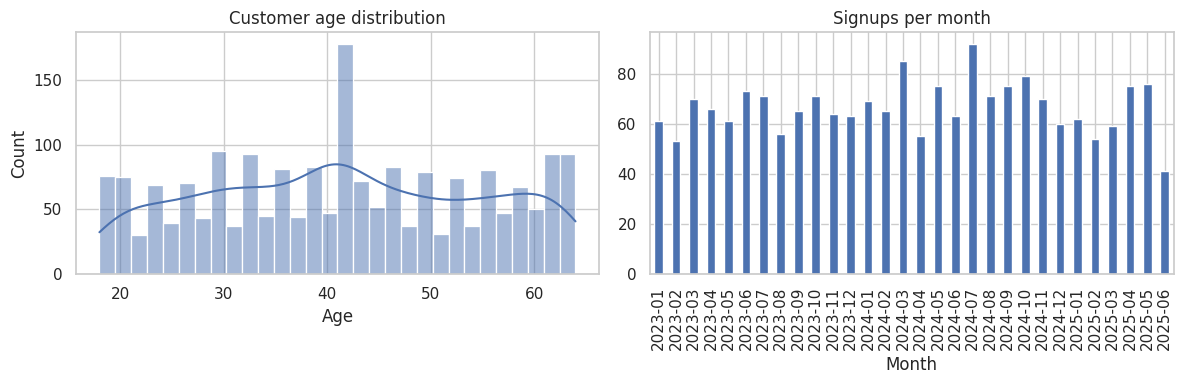

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(dim_customer["age"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Customer age distribution")
axes[0].set_xlabel("Age")

signup = pd.to_datetime(dim_customer["signup_date"])
signup.dt.to_period("M").value_counts().sort_index().plot(kind="bar", ax=axes[1])
axes[1].set_title("Signups per month")
axes[1].set_xlabel("Month")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [5]:
dim_customer["age"].describe().round(1)

count    2000.0
mean       41.4
std        13.2
min        18.0
25%        31.0
50%        41.0
75%        52.0
max        64.0
Name: age, dtype: float64

**Observation:** the age distribution is roughly uniform across the
synthetic range rather than the bell-shaped curve you'd expect from a real
customer base — a giveaway that this is generated data. If a real
customer-age column suddenly looked this uniform, that would itself be a
DQ smell worth a check (e.g. a range/distribution check, not just a
min/max bound), which is the kind of thing `dq/validation.py`'s numeric
schema checks (`min`/`max`) catch but a distribution check wouldn't — an
extension worth adding if this dataset were real.

## 3. Products — price distributions by category

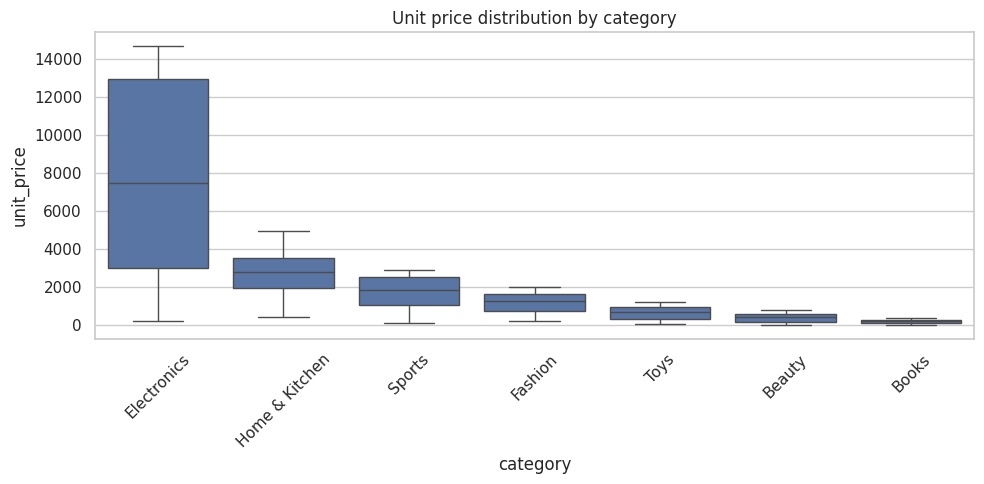

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
order = dim_product.groupby("category")["unit_price"].median().sort_values(ascending=False).index
sns.boxplot(data=dim_product, x="category", y="unit_price", order=order, ax=ax)
ax.set_title("Unit price distribution by category")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

In [7]:
dim_product.groupby("category").agg(
    n_products=("product_id", "count"),
    median_price=("unit_price", "median"),
    median_margin_pct=("margin_pct", "median"),
).sort_values("n_products", ascending=False)

,n_products,median_price,median_margin_pct
category,,,
Toys,51,672.070,0.30500
Fashion,50,1261.860,0.37100
Electronics,46,7467.900,0.39445
Home & Kitchen,42,2808.045,0.34835
Beauty,42,404.850,0.41480
Sports,36,1869.145,0.33005
Books,33,221.120,0.37810


**Observation → DQ link:** `unit_price` and `cost_price` are both
non-negative in every category here (see `dim_product`'s DQ schema:
`{"unit_price": {"type": "numeric", "min": 0}}` in `etl/pipeline.py`'s
`DQ_TABLE_CONFIGS`). That range check exists *because* a negative price
is a meaningless value for this table — the kind of rule that's obvious
once you've actually looked at the distribution, not before.

## 4. Sales over time

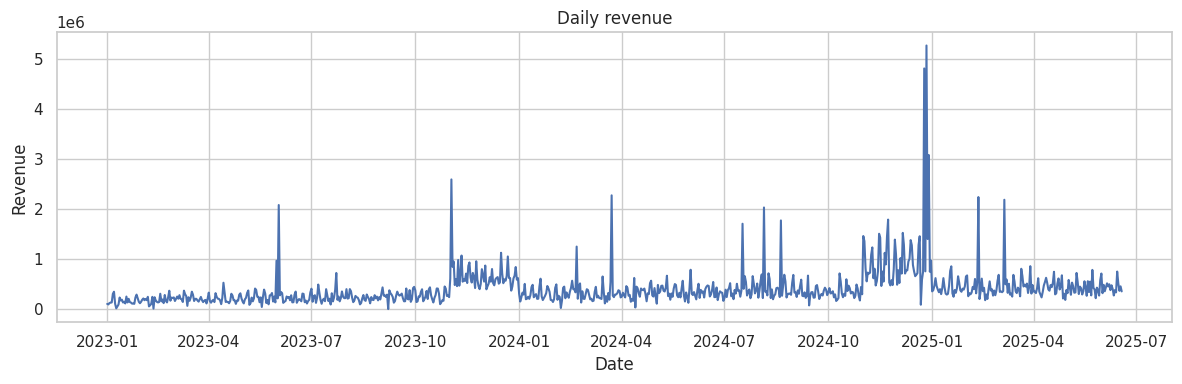

,date_id,revenue,n_orders
count,900,900.0,900.0
mean,2024-03-25 11:59:59.999999744,408469.3,95.6
min,2023-01-01 00:00:00,6847.3,4.0
25%,2023-08-13 18:00:00,226651.8,55.0
50%,2024-03-25 12:00:00,324484.4,75.0
75%,2024-11-05 06:00:00,468579.3,111.0
max,2025-06-18 00:00:00,5272588.4,1307.0
std,NaN,372228.4,86.5


In [8]:
daily_revenue = pd.read_sql('''
    SELECT d.date_id, SUM(f.total_amount) AS revenue, COUNT(*) AS n_orders
    FROM fact_sales f JOIN dim_date d ON f.date_id = d.date_id
    GROUP BY d.date_id ORDER BY d.date_id
''', conn, parse_dates=["date_id"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_revenue["date_id"], daily_revenue["revenue"])
ax.set_title("Daily revenue")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()

daily_revenue.describe().round(1)

## 5. Anomaly days (from `ml/anomaly_detection.py`)

In [9]:
anomaly_path = os.path.join(REPO_ROOT, "models", "anomaly_results_lookup.csv")
if os.path.exists(anomaly_path):
    anomalies = pd.read_csv(anomaly_path)
    top_anomalies = anomalies.sort_values("anomaly_score", ascending=False).head(10) if "anomaly_score" in anomalies.columns else anomalies.head(10)
    display(top_anomalies)
else:
    print("models/anomaly_results_lookup.csv not found — run `python3 run_all.py` (or api/train_and_save_models.py) first.")

,date_id,revenue,n_orders,day_of_week,month,revenue_zscore_by_weekday,anomaly,anomaly_score
447,2024-03-25,224518.13,20,0,3,-0.266019,1,0.293976
440,2024-03-18,206716.58,20,0,3,-0.361003,1,0.293875
807,2025-03-20,222574.49,24,3,3,-0.263674,1,0.293833
384,2024-01-21,227833.09,21,6,1,-0.227287,1,0.293827
77,2023-03-20,207121.60,18,0,3,-0.358842,1,0.293609
625,2024-09-19,208846.86,20,3,9,-0.315689,1,0.293483
422,2024-02-29,226932.24,22,3,2,-0.247162,1,0.293313
741,2025-01-13,227672.84,24,0,1,-0.249186,1,0.293217
735,2025-01-07,228038.98,22,1,1,-0.219293,1,0.293128
245,2023-09-04,229285.73,21,0,9,-0.240580,1,0.293027


## 6. Reviews & sentiment (`fact_reviews`)

12,871 reviews


,rating,sentiment_label,sentiment_score,word_count
count,12871.000000,12871,12871.000000,12871.000000
unique,NaN,3,NaN,NaN
top,NaN,positive,NaN,NaN
freq,NaN,7032,NaN,NaN
mean,3.439049,NaN,0.649134,9.296170
std,1.338856,NaN,1.784756,3.256062
min,1.000000,NaN,-4.000000,5.000000
25%,3.000000,NaN,0.000000,6.000000
50%,4.000000,NaN,1.000000,9.000000
75%,5.000000,NaN,2.000000,12.000000


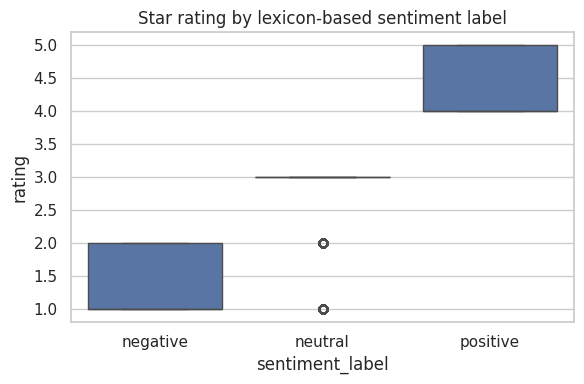

In [10]:
if "fact_reviews" in tables["name"].values:
    fact_reviews = pd.read_sql("SELECT * FROM fact_reviews", conn)
    print(f"{len(fact_reviews):,} reviews")
    display(fact_reviews[["rating", "sentiment_label", "sentiment_score", "word_count"]].describe(include="all"))

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.boxplot(data=fact_reviews, x="sentiment_label", y="rating", ax=ax,
                order=["negative", "neutral", "positive"])
    ax.set_title("Star rating by lexicon-based sentiment label")
    plt.tight_layout()
    plt.show()
else:
    print("fact_reviews not found — run `python3 etl/process_reviews.py` (or `run_all.py`, which now includes this step) first.")

**Observation:** the lexicon-based sentiment in `etl/process_reviews.py`
(`POSITIVE_WORDS`/`NEGATIVE_WORDS` sets of Egyptian-Arabic terms) tracks
star rating reasonably well on this synthetic set — see the boxplot above.
It's a small, dependency-free method that works without downloading any
model. `etl/process_reviews.py` also supports an optional Hugging Face
backend (`--backend hf`) for a real transformer-based multilingual
sentiment model, with an automatic fallback to this lexicon if
`transformers` isn't installed — see that file's own docstring for the
accuracy comparison and trade-offs.

## 7. DQ scores for these tables, and how EDA fed back into the rules

In [11]:
if os.path.exists(DQ_HISTORY_PATH):
    dq_conn = sqlite3.connect(DQ_HISTORY_PATH)
    history = pd.read_sql('''
        SELECT dataset_name, run_timestamp, total_rows, overall_score
        FROM quality_runs
        WHERE dataset_name LIKE 'etl.%'
        ORDER BY run_timestamp DESC
    ''', dq_conn)
    latest_per_table = history.sort_values("run_timestamp").groupby("dataset_name").tail(1)
    display(latest_per_table)
else:
    print("dq/quality_history.db not found — run `python3 run_all.py` from the repo root first.")

,dataset_name,run_timestamp,total_rows,overall_score
2,etl.dim_customer,2026-09-20T07:03:18.897514+00:00,2000,100.0
1,etl.dim_product,2026-09-20T07:03:18.907240+00:00,300,92.7
0,etl.fact_sales,2026-09-20T07:03:18.979616+00:00,86052,92.0


**Notes tying the EDA back into the DQ system** (see
`etl/pipeline.py`'s `DQ_TABLE_CONFIGS` and `dq/quality_gate.py`):

- Section 2 showed `age` is bounded and never negative in this dataset →
  `dim_customer`'s DQ schema checks `age` is between 0 and 120.
- Section 3 showed prices are always non-negative → `dim_product`'s DQ
  schema checks `unit_price >= 0`.
- Section 4/5's daily revenue and anomaly view is exactly what the DQ
  gate protects: if a bad extract ever dropped `fact_sales` rows or
  introduced negative quantities, the gate blocks the load before this
  kind of daily-revenue chart could go quietly wrong in production.
- `dim_product`'s and `fact_sales`'s scores land below 100 (92.7 and 92.0
  in the run this notebook was built against) rather than at 100 — that's
  expected: the DQ scorer penalizes outliers/consistency violations even
  on data that ETL's own `validate_all()` expectations already accept, so
  a lower-than-100 score doesn't necessarily mean the gate should block
  it. That gap between "passes hard validation" and "scores 100" is a
  deliberate design choice worth calling out, not a bug.